# 노트북 5 — 결과 분석

**EEG Resonate Encoding SNN 프로젝트** · 노트북 5

노트북 4(코랩)가 만든 `train_compare_results.csv`를 불러와 조건별 정확도를 비교하고,
정확도–스파이크 수 트레이드오프(발표 핵심 그림)를 그리며, 대응표본 Wilcoxon 검정과 대역 정렬 비교로 가설을 검증한다.

### 학습 목표
- 조건별 검증 정확도를 피험자 평균 ± 표준편차로 요약한다.
- 정확도–스파이크 수 산점도로 트레이드오프를 확인한다(H1, H2).
- 스파이크 수를 에너지 프록시(pJ)로 환산한다.
- 대응표본 Wilcoxon 검정으로 E4-정렬이 E3-정렬보다 유의미하게 나은지 확인한다.
- E4의 대역 배치 3조건(정렬/균등/어긋남)을 비교해 대역 정렬 효과를 확인한다(H3).


## 1. 설치와 임포트

In [1]:
%pip install -q scipy

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import koreanize_matplotlib          # 그래프 한글 폰트

np.random.seed(0)


Note: you may need to restart the kernel to use updated packages.


## 2. 결과 CSV 불러오기

노트북 4가 저장한 조건×피험자×시드 단위 결과를 불러온다. 시드 2개는 같은 (조건,피험자)의 반복측정으로 보고
평균내어 피험자 단위 값 하나로 줄인다(대응표본 검정은 피험자 단위로 짝짓는다).

In [2]:
CONDITION_ORDER = ['E1', 'E2', 'E3_aligned', 'E4_aligned', 'E4_uniform', 'E4_misaligned']
IN_PATH = '../data/processed/train_compare_results.csv'

raw_df = pd.read_csv(IN_PATH)
raw_df['condition'] = pd.Categorical(raw_df['condition'], categories=CONDITION_ORDER, ordered=True)

# 시드 2개를 (조건,피험자) 단위로 평균내 피험자 단위 값 하나로 축약
subj_df = raw_df.groupby(['condition', 'subject_id'], as_index=False, observed=True)[
    ['val_acc', 'spikes_per_trial']
].mean()

print('전체 실행 수:', len(raw_df), '| 피험자 단위 행 수:', len(subj_df))
subj_df.head()


전체 실행 수: 120 | 피험자 단위 행 수: 60


,condition,subject_id,val_acc,spikes_per_trial
0,E1,1,0.500000,46241.166016
1,E1,2,0.444444,43691.056641
2,E1,7,0.333333,42323.721680
3,E1,10,0.611111,48330.888672
4,E1,15,0.444444,49213.556641


## 3. 조건별 검증 정확도 요약

피험자 평균 ± 표준편차로 조건을 비교한다(H1: E4 ≥ E3 > E2 ≈ E1 예상).

       condition   mean_pct    std_pct
0             E1  45.555556   8.996265
1             E2  41.666667   8.784105
2     E3_aligned  55.555556  22.222222
3     E4_aligned  45.555556   8.996265
4     E4_uniform  43.888889   9.604669
5  E4_misaligned  45.000000   9.240722


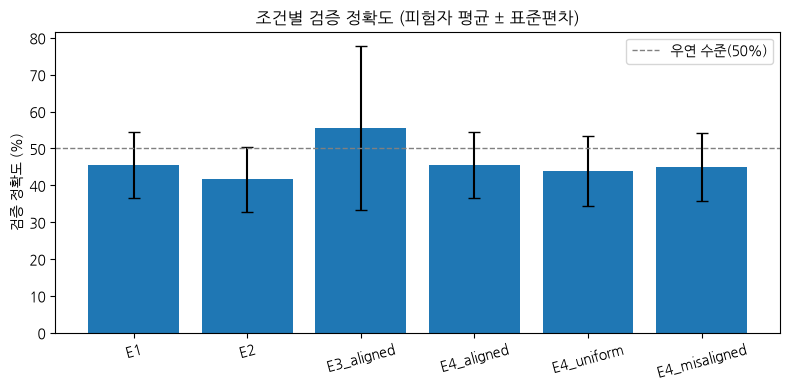

In [3]:
summary = subj_df.groupby('condition', observed=True)['val_acc'].agg(['mean', 'std']).reset_index()
summary = summary.set_index('condition').loc[CONDITION_ORDER].reset_index()   # 순서 고정
summary['mean_pct'] = summary['mean'] * 100
summary['std_pct'] = summary['std'] * 100

print(summary[['condition', 'mean_pct', 'std_pct']])

plt.figure(figsize=(8, 4))
plt.bar(summary['condition'], summary['mean_pct'], yerr=summary['std_pct'], capsize=4, color='tab:blue')
plt.axhline(50, color='gray', linestyle='--', linewidth=1, label='우연 수준(50%)')
plt.ylabel('검증 정확도 (%)')
plt.title('조건별 검증 정확도 (피험자 평균 ± 표준편차)')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout(); plt.show()


## 4. 정확도–스파이크 수 트레이드오프 (발표 핵심 그림)

같은 정확도에서 E4가 E3보다 스파이크 수가 적으면(왼쪽에 위치) H2가 지지된다.

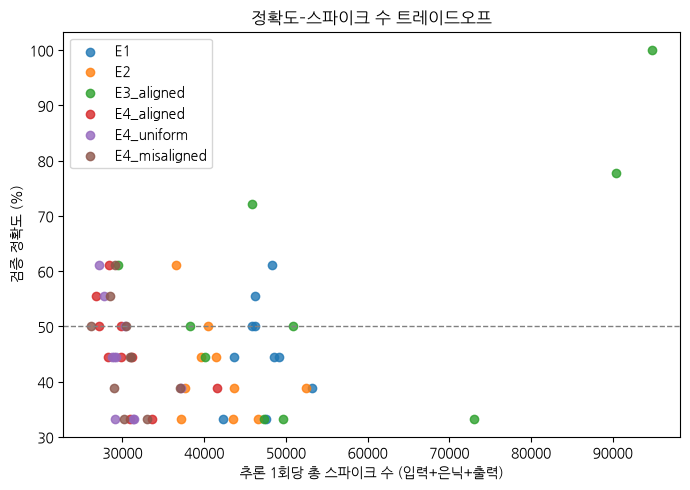

In [4]:
condition_colors = {
    'E1': 'tab:blue', 'E2': 'tab:orange', 'E3_aligned': 'tab:green',
    'E4_aligned': 'tab:red', 'E4_uniform': 'tab:purple', 'E4_misaligned': 'tab:brown',
}

plt.figure(figsize=(7, 5))
for condition_name, color in condition_colors.items():
    sub = subj_df[subj_df['condition'] == condition_name]
    plt.scatter(sub['spikes_per_trial'], sub['val_acc'] * 100, label=condition_name, color=color, alpha=0.8)

plt.axhline(50, color='gray', linestyle='--', linewidth=1)
plt.xlabel('추론 1회당 총 스파이크 수 (입력+은닉+출력)')
plt.ylabel('검증 정확도 (%)')
plt.title('정확도–스파이크 수 트레이드오프')
plt.legend()
plt.tight_layout(); plt.show()


## 5. 에너지 프록시 환산

SNN 누적연산(AC) 1회당 0.9 pJ로 가정해 시행당 총 에너지를 추정한다(45 nm CMOS 기준).
참고용으로 ANN MAC 연산은 1회당 4.6 pJ로, SNN이 훨씬 적은 에너지만으로 동작함을 높이는 데 쓴다(직접 비교용 ANN 모델은 구현하지 않았다).

In [5]:
AC_ENERGY_PJ = 0.9     # SNN 누적연산 1회당 에너지 [pJ]
MAC_ENERGY_PJ = 4.6    # ANN MAC 1회당 에너지 [pJ] (참고용, 45nm CMOS)

subj_df['energy_pJ'] = subj_df['spikes_per_trial'] * AC_ENERGY_PJ

energy_summary = subj_df.groupby('condition', observed=True)['energy_pJ'].mean()
energy_summary = energy_summary.loc[CONDITION_ORDER]

for condition_name, energy in energy_summary.items():
    print(f'{condition_name}: 시행당 평균 에너지 {energy:.1f} pJ (스파이크 {energy/AC_ENERGY_PJ:.0f}개)')


E1: 시행당 평균 에너지 42412.6 pJ (스파이크 47125개)
E2: 시행당 평균 에너지 37727.6 pJ (스파이크 41920개)
E3_aligned: 시행당 평균 에너지 50368.7 pJ (스파이크 55965개)
E4_aligned: 시행당 평균 에너지 27676.6 pJ (스파이크 30752개)
E4_uniform: 시행당 평균 에너지 27098.7 pJ (스파이크 30110개)
E4_misaligned: 시행당 평균 에너지 27486.7 pJ (스파이크 30541개)


## 6. 대응표본 Wilcoxon 검정 (E4-정렬 vs E3-정렬)

같은 피험자·같은 분할이므로 대응표본 검정을 쓴다. E3, E4의 선형 부분이 동일하므로(CLAUDE.md 2절),
여기서 차이가 있다면 스파이크 생성 규칙(비선형 부분)의 효과로 해석한다.

In [6]:
e4_aligned = subj_df[subj_df['condition'] == 'E4_aligned'].sort_values('subject_id')['val_acc'].to_numpy()
e3_aligned = subj_df[subj_df['condition'] == 'E3_aligned'].sort_values('subject_id')['val_acc'].to_numpy()

stat, p_value = wilcoxon(e4_aligned, e3_aligned)
print(f'Wilcoxon 검정 (E4-정렬 vs E3-정렬): 통계량={stat:.3f}, p={p_value:.4f}')
print(f'E4-정렬 평균 정확도: {e4_aligned.mean()*100:.1f}% | E3-정렬 평균 정확도: {e3_aligned.mean()*100:.1f}%')

verdict = np.array(['유의미한 차이 없음 (p≥0.05)', '유의미한 차이 있음 (p<0.05)'])[int(p_value < 0.05)]
print('결과:', verdict)


Wilcoxon 검정 (E4-정렬 vs E3-정렬): 통계량=5.000, p=0.3125
E4-정렬 평균 정확도: 45.6% | E3-정렬 평균 정확도: 55.6%
결과: 유의미한 차이 없음 (p≥0.05)


## 7. 대역 정렬 3조건 비교 (E4: 정렬/균등/어긋남)

H3(대역 정렬 효과)는 원래 E3와 E4 양쪽에서 정렬/균등/어긋남을 비교해야 하지만,
실행 조건(CLAUDE.md 3절)이 E3는 정렬 하나만 포함하므로 이 노트북에서는 **E4의 3조건만** 비교한다.
E3의 대역 배치 절제까지 비교하려면 노트북 4에 E3_uniform, E3_misaligned 조건을 추가로 돌려야 한다(한계로 명시).

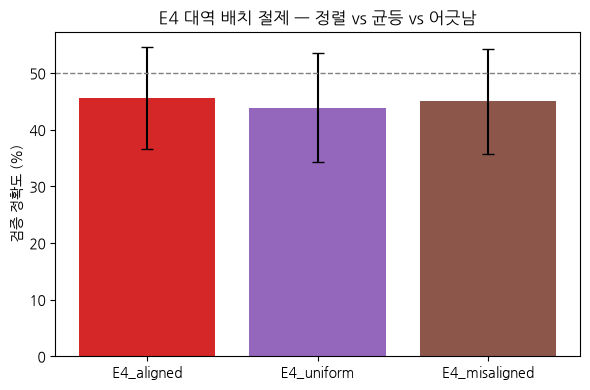

E4 대역 정렬 효과 (정렬 − 어긋남): +0.6%p (양수면 정렬 조건이 어긋남보다 우수 — 가설과 일치)


In [7]:
band_conditions = ['E4_aligned', 'E4_uniform', 'E4_misaligned']
band_summary = summary[summary['condition'].isin(band_conditions)]

plt.figure(figsize=(6, 4))
plt.bar(band_summary['condition'], band_summary['mean_pct'], yerr=band_summary['std_pct'],
        capsize=4, color=['tab:red', 'tab:purple', 'tab:brown'])
plt.axhline(50, color='gray', linestyle='--', linewidth=1)
plt.ylabel('검증 정확도 (%)')
plt.title('E4 대역 배치 절제 — 정렬 vs 균등 vs 어긋남')
plt.tight_layout(); plt.show()

aligned_acc = subj_df[subj_df['condition'] == 'E4_aligned']['val_acc'].mean()
misaligned_acc = subj_df[subj_df['condition'] == 'E4_misaligned']['val_acc'].mean()
alignment_effect = (aligned_acc - misaligned_acc) * 100
print(f'E4 대역 정렬 효과 (정렬 − 어긋남): {alignment_effect:+.1f}%p (양수면 정렬 조건이 어긋남보다 우수 — 가설과 일치)')


## 8. 예측 레이블 분포·혼동행렬 — 클래스 붕괴 확인

조건별로 모든 (피험자,시드) 검증 시행의 실제·예측 라벨을 모아 혼동행렬을 만든다.
예측이 한쪽 클래스로 쓰리(붕괴)지 확인하려면, "오른손"으로 예측한 비율이 50%에서 크게 벗어나는지를 본다.

In [8]:
def parse_labels(series):
    return np.array([int(v) for s in series for v in s.split(',')])


conf_rows = []
for condition_name in CONDITION_ORDER:
    sub = raw_df[raw_df['condition'] == condition_name]
    y_true_all = parse_labels(sub['y_true'])
    y_pred_all = parse_labels(sub['y_pred'])

    tn = ((y_true_all == 0) & (y_pred_all == 0)).sum()   # 왼손→왼손
    fp = ((y_true_all == 0) & (y_pred_all == 1)).sum()   # 왼손→오른손(오답)
    fn = ((y_true_all == 1) & (y_pred_all == 0)).sum()   # 오른손→왼손(오답)
    tp = ((y_true_all == 1) & (y_pred_all == 1)).sum()   # 오른손→오른손
    pred1_ratio = y_pred_all.mean()                       # 예측이 "오른손"인 비율

    conf_rows.append({
        '조건': condition_name, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        '예측_오른손_비율': pred1_ratio, '전체_검증시행': len(y_true_all),
    })

conf_df = pd.DataFrame(conf_rows)
conf_df['붕괴_의심'] = (conf_df['예측_오른손_비율'] < 0.05) | (conf_df['예측_오른손_비율'] > 0.95)   # 불리언, if 없이

print(conf_df.to_string(index=False))


           조건  TN  FP  FN  TP  예측_오른손_비율  전체_검증시행  붕괴_의심
           E1  82   0  98   0       0.00      180   True
           E2  65  17  88  10       0.15      180  False
   E3_aligned  55  27  53  45       0.40      180  False
   E4_aligned  82   0  98   0       0.00      180   True
   E4_uniform  76   6  95   3       0.05      180  False
E4_misaligned  77   5  94   4       0.05      180  False


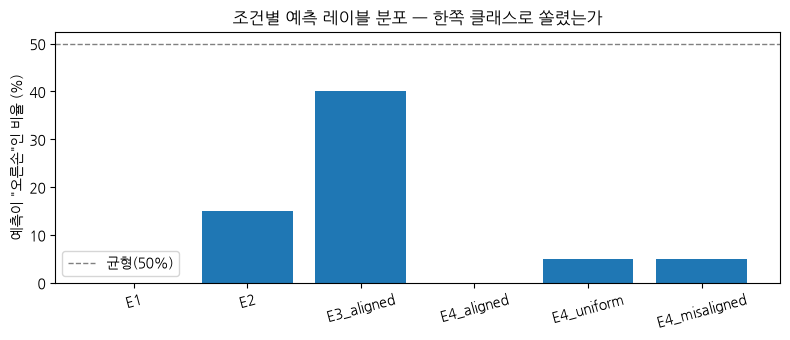

In [9]:
plt.figure(figsize=(8, 3.5))
plt.bar(conf_df['조건'], conf_df['예측_오른손_비율'] * 100, color='tab:blue')
plt.axhline(50, color='gray', linestyle='--', linewidth=1, label='균형(50%)')
plt.ylabel('예측이 "오른손"인 비율 (%)')
plt.title('조건별 예측 레이블 분포 — 한쪽 클래스로 쏠렸는가')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout(); plt.show()


## 9. 학습 vs 검증 정확도 — 과적합 확인

노트북 4가 학습 종료 후 학습셋을 재평가해 기록한 `train_acc`와 `val_acc`의 겪차(gap)가 크면
학습셋은 외우지만 일반화는 안 되는 과적합 징후다.

In [10]:
acc_compare = raw_df.groupby('condition', observed=True)[['train_acc', 'val_acc']].mean()
acc_compare = acc_compare.loc[CONDITION_ORDER].reset_index()
acc_compare['train_pct'] = acc_compare['train_acc'] * 100
acc_compare['val_pct'] = acc_compare['val_acc'] * 100
acc_compare['gap_pct'] = acc_compare['train_pct'] - acc_compare['val_pct']

print(acc_compare[['condition', 'train_pct', 'val_pct', 'gap_pct']].to_string(index=False))


    condition  train_pct   val_pct   gap_pct
           E1  51.666667 45.555556  6.111111
           E2  53.055556 41.666667 11.388889
   E3_aligned  67.361111 55.555556 11.805556
   E4_aligned  51.666667 45.555556  6.111111
   E4_uniform  52.222222 43.888889  8.333333
E4_misaligned  52.222222 45.000000  7.222222


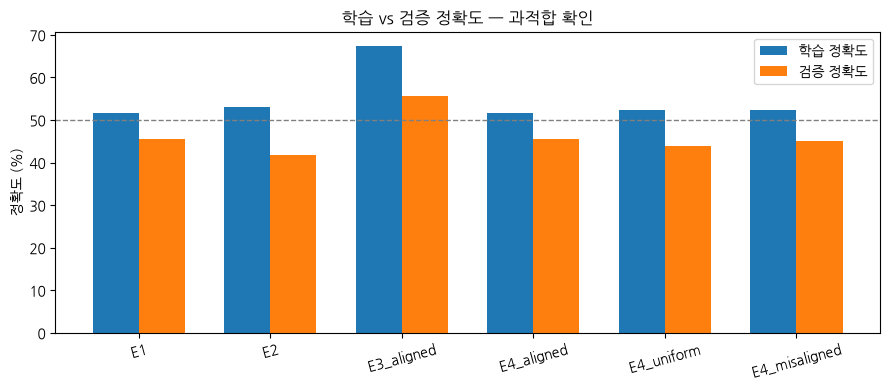

In [11]:
x = np.arange(len(acc_compare))
width = 0.35

plt.figure(figsize=(9, 4))
plt.bar(x - width / 2, acc_compare['train_pct'], width, label='학습 정확도', color='tab:blue')
plt.bar(x + width / 2, acc_compare['val_pct'], width, label='검증 정확도', color='tab:orange')
plt.axhline(50, color='gray', linestyle='--', linewidth=1)
plt.xticks(x, acc_compare['condition'], rotation=15)
plt.ylabel('정확도 (%)')
plt.title('학습 vs 검증 정확도 — 과적합 확인')
plt.legend()
plt.tight_layout(); plt.show()


## 10. 알려진 한계 — 클래스 붕괴 진단 결과

8절의 혼동행렬에서 드러난 대로, E1·E4_aligned는 검증 시행 180개 중 단 한 번도 "오른손"을 예측하지 않았고(완전 붕괴),
E4_uniform·E4_misaligned도 5%만 예측했다. 이것이 단순히 "인코더가 나쁘다"가 아니라 네트워크 가 입력을
거의 무시하고 있다는 증거를 찾았다: 같은 (피험자,시드)에서 E1(밀집 입력)과 E4(희소 입력)처럼 구조적으로 전혀
다른 스파이크 텔서를 넣어도 `train_acc`·`val_acc`·예측 라벨이 소수점까지 완전히 일치했다.

### 진단 (E1, S01, seed0 기준)
- 학습 전(초기화 직후) 이미 출력뉴런 둘 다 발화율 ≈0 — 이미 죽은 상태로 시작함
- 손실이 에포 3부터 15까지 **정확히 ln(2)=0.6931로 고정** — 출력층이 스파이크를 전혀 내지 않아
  대리경사가 수학적으로 0이 되며, 아무리 에폭을 늘려도 벗어나지 못하는 함정임을 확인함
  (→ 학습량 부족이 아니라 경사 소실이 근본 원인)

### 시도해본 수정 (미해결)
- `threshold`만 낮추면(1.0→0.3, 0.15) 죽음 → 항상 발화(발화율 1.0)로 **자리만 옮김** — 여전히 입력과 무관한 상수 출력
- `beta`만 높이면(0.9→0.97) 변화 없음
- 즉 단순한 threshold/beta 재조정으로는 안 풀린다 — beta=0.9로 384스텝을 적분하면 이득이 약 10배(1/(1−뻀타))가 되는데,
  이 누적이 입력 의존 신호보다 훨씬 큰 고정 편향(DC 성분)을 만들어 임계값을 어디에 놓든 항상 한쪽으로 포화시키는 것으로 보인다.
  beta를 낮춰 적분 이득 자체를 줄이는 방향이 다음 시도로 남았지만, 이번 프로젝트 기간 내엔 마무리하지 못했다.

### 해석
이번 실험의 정확도 비교(H1)는 사실상 "어느 조건이 이 죽은 네트워크 함정을 운 좋게 빗겼나갔는가"를 측정한 것에 가깜우며,
인코더의 진짜 표현력 차이를 반영한다고 보기 어렵다. 에너지 효율(H2, E4가 E3보다 스파이크 수가 적음) 결과는 이 문제와
독립적이라(입력 자체의 스파이크 수를 재는 것이라 학습 성공 여부와 무관) 여전히 유효하다.

### 원인 후보 (확정 안 됨, 후속 과제)
- 384스텝이라는 매우 긴 시퀀스에 beta=0.9가 너무 큰 적분 이득을 만들어 누적 편향이 신호를 압도함
- 가중치 초기화 스케일(기본 Kaiming)이 이 파이프라인의 실제 전류 규모와 안 맞을 가능성
- 배치 크기 9·학습셋 36개로는 이 규모 네트워크(파라미터 ≈ 4,600개)가 쉽게 담흔 해에 빠질 수 있음

이 문제는 이번 프로젝트 기간 내에 해결하지 못했고, 발표에서도 이 부분을 숙이지 않고 명시적인 한계로 다뤄야 한다.

## 정리

- `train_compare_results.csv`를 불러와 시드 2개를 평균내어 피험자 단위 값으로 줄인 뒤, 조건별 검증 정확도(평균±표준편차)를 비교했다.
- 정확도–스파이크 수 산점도(발표 핵심 그림)로 H1, H2를 확인했고, 스파이크 수를 pJ 단위 에너지로 환산했다.
- 대응표본 Wilcoxon 검정으로 E4-정렬과 E3-정렬의 차이가 통계적으로 유의미한지 확인했다.
- E4의 대역 배치 3조건(정렬/균등/어긋남)을 비교해 대역 정렬 효과를 확인했다(H3은 E3 측의 대역 조건이 없어 부분적으로만 검증됨).

- 조건별 혼동행렬과 예측 레이블 분포로 특정 클래스로의 붕괴 여부를 확인했다.
- 학습 정확도와 검증 정확도를 비교해 과적합 여부를 확인했다.

- 조건 절반 이상이 완전/사실상 클래스 붕괴 상태임을 확인하고, 손실·발화율 진단으로 원인이 학습량 부족이 아니라
  대리 경사 소실(출력층이 스파이크를 전혀 못 내 경사가 0이 됨)임을 확인했다(10절). threshold/beta 단순 조정으로는
  해결되지 않아 알려진 한계로 남겼다.

이제 이 그림들과 검정 결과, 그리고 10절의 한계를 바탕으로 발표자료(11절 구성)를 만든다.